In [ ]:
import pandas as pd

# Load the combined dataset containing text and emoji labels
data = pd.read_csv('combined_data.csv')

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

X = data["text_without_emoji"].tolist()
y = data["emoji_label"].tolist()

# Split data into training and testing sets
# random_state=12 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# Encode emoji labels as integers because sklearn models require numeric targets
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)
print("Number of emoji classes:", num_classes)

# Convert text to numerical features using TF-IDF (Term Frequency-Inverse Document Frequency)
# max_features=5000: Limit vocabulary to top 5000 terms to reduce dimensionality and noise
# ngram_range=(1, 2): Include both unigrams (single words) and bigrams (two-word phrases) to capture context
vectorizer = TfidfVectorizer(
    max_features=5000,  
    ngram_range=(1, 2)  
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Base KNN model
# n_jobs=-1 uses all available CPU cores for faster computation
base_knn = KNeighborsClassifier(n_jobs=-1)

# Define hyperparameter grid for tuning
# n_neighbors: Number of neighbors to use (k)
# weights: 'uniform' treats all neighbors equally, 'distance' weights closer neighbors more heavily
# metric: 'cosine' similarity is generally better for high-dimensional text data (TF-IDF) than Euclidean distance
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["cosine"]
}

# Perform Grid Search with Cross-Validation to find the best hyperparameters
grid = GridSearchCV(
    estimator=base_knn,
    param_grid=param_grid,
    cv=3,                # 3-fold cross-validation to validate performance on different subsets of training data
    scoring="accuracy",  # Optimize for accuracy
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_tfidf, y_train_enc)

print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

# Display results of the grid search
results = pd.DataFrame(grid.cv_results_)
display(
    results[[
        "param_n_neighbors",
        "param_weights",
        "param_metric",
        "mean_test_score",
        "std_test_score"
    ]].sort_values("mean_test_score", ascending=False)
)

# Use the best model found by GridSearch
best_knn = grid.best_estimator_

# Evaluate on the held-out test set
y_pred = best_knn.predict(X_test_tfidf)

accuracy = accuracy_score(y_test_enc, y_pred)
print("Test accuracy with best KNN:", accuracy)

print("\nClassification Report (best KNN):")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Number of emoji classes: 43
Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Code\ATDS\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan 0.14043624
 0.13773879 0.14347233 0.13977205 0.14550996]
  warnings.warn(


Best parameters: {'metric': 'cosine', 'n_neighbors': 11, 'weights': 'distance'}
Best cross-validation accuracy: 0.14550995849175066


,param_n_neighbors,param_weights,param_metric,mean_test_score,std_test_score
9,11,distance,cosine,0.145510,0.000803
7,9,distance,cosine,0.143472,0.000712
5,7,distance,cosine,0.140436,0.000446
8,11,uniform,cosine,0.139772,0.001100
6,9,uniform,cosine,0.137739,0.001004
0,3,uniform,cosine,NaN,NaN
1,3,distance,cosine,NaN,NaN
2,5,uniform,cosine,NaN,NaN
3,5,distance,cosine,NaN,NaN
4,7,uniform,cosine,NaN,NaN


Test accuracy with best KNN: 0.1507484812371014

Classification Report (best KNN):
                               precision    recall  f1-score   support

backhand_index_pointing_right       0.50      0.46      0.48      4020
                   check_mark       0.34      0.33      0.33      4019
            check_mark_button       0.35      0.37      0.36      3928
                   clown_face       0.13      0.11      0.12      4094
                      cooking       0.23      0.28      0.25      3919
                          egg       0.13      0.29      0.18      4034
                 enraged_face       0.12      0.11      0.11      4093
                         eyes       0.10      0.12      0.11      4058
      face_holding_back_tears       0.08      0.10      0.09      4080
           face_savoring_food       0.13      0.18      0.15      3970
    face_with_steam_from_nose       0.07      0.06      0.07      4049
       face_with_tears_of_joy       0.11      0.11      0.11    

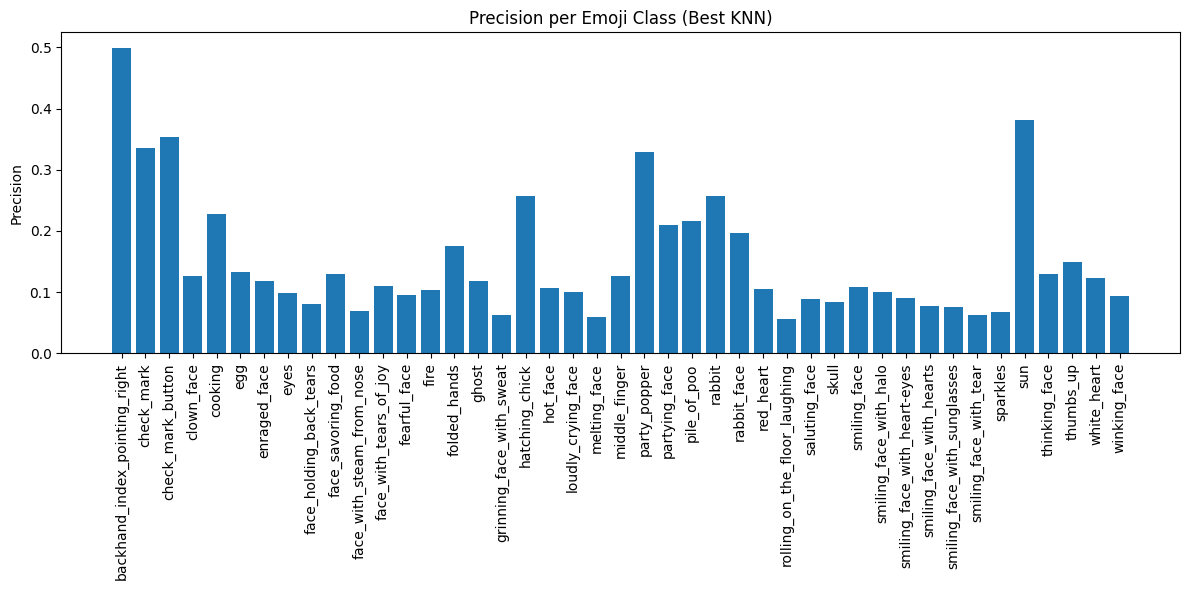

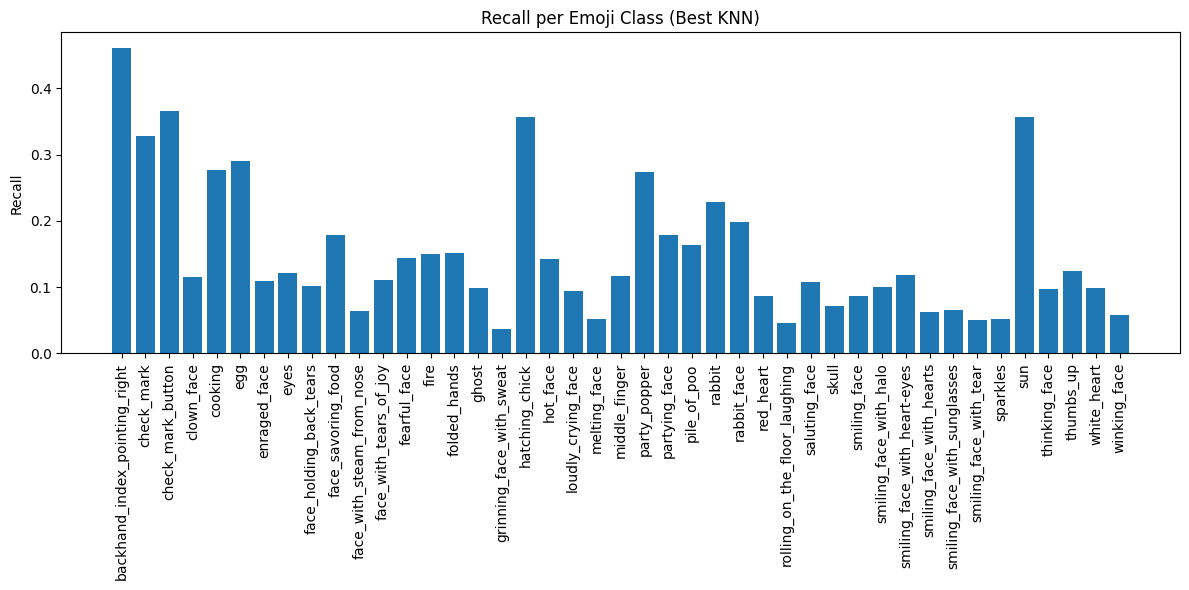

In [ ]:
import matplotlib.pyplot as plt

# Calculate precision and recall for each class
# Precision: Of all instances predicted as class X, how many were actually class X?
# Recall: Of all actual instances of class X, how many were correctly predicted?
precisions = precision_score(y_test_enc, y_pred, average=None, zero_division=0)
recalls = recall_score(y_test_enc, y_pred, average=None, zero_division=0)

# Visualize Precision per class
plt.figure(figsize=(12, 6))
plt.bar(le.classes_, precisions)
plt.xticks(rotation=90)
plt.ylabel("Precision")
plt.title("Precision per Emoji Class (Best KNN)")
plt.tight_layout()
plt.show()

# Visualize Recall per class
plt.figure(figsize=(12, 6))
plt.bar(le.classes_, recalls)
plt.xticks(rotation=90)
plt.ylabel("Recall")
plt.title("Recall per Emoji Class (Best KNN)")
plt.tight_layout()
plt.show()